# Supervised Baseline & Linear Probe Evaluation

**By: Mirna Imbabi** · Student C: Linear Evaluation & Reporting Lead

---

This notebook will cover **two things**:

1. **Supervised Baseline** : Train a ResNet50 from scratch on CIFAR-10 with standard Cross-Entropy. This gives us the "ceiling" which is the best accuracy a fully labeled model can reach. Everything SimCLR does will be measured against this number.

2. **Linear Probe Evaluation** : After SimCLR pretraining (done by Mahmoud), we freeze the encoder and train only a single linear layer on top. This is how we measure whether the unsupervised representations actually learned something useful.

> If our linear probe gets close to the supervised baseline, it means SimCLR extracted genuinely semantic features without ever seeing a single label during pretraining.

---


In [ ]:
uv install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


d:\Deep Learning Project\Midterm\venv\Scripts\python.exe: No module named uv


## Setup & Imports


In [ ]:
import os, time, random, csv
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# Force GPU usage if available
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'CUDA Version: {torch.version.cuda}')
if torch.cuda.is_available():
    print(f'GPU Count: {torch.cuda.device_count()}')
    torch.cuda.set_device(0)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {device}')
if device.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Path('logs').mkdir(exist_ok=True)
Path('checkpoints').mkdir(exist_ok=True)
print('Folders : logs/ and checkpoints/ ready')

CUDA Available: True
CUDA Version: 12.1
GPU Count: 1
Device  : cuda:0
GPU     : NVIDIA RTX 5000 Ada Generation
VRAM    : 34.4 GB
Folders : logs/ and checkpoints/ ready


## 1 · Dataset: CIFAR-10

60,000 tiny 32×32 images across 10 classes (airplane, car, bird, cat, deer, dog, frog, horse, ship, truck). 50k for training, 10k for testing.

For the supervised baseline, we'll use a standard augmentation pipeline:
- `RandomCrop(32, padding=4)`: shifts the image a bit in each direction
- `RandomHorizontalFlip`: flips left-right 50% of the time
- Normalize with CIFAR-10 mean & std

> This is intentionally different from SimCLR's augmentation (which is much more aggressive). We want a fair supervised baseline, not one artificially hampered.


In [ ]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_set = datasets.CIFAR10('./data', train=True,  download=True, transform=train_transform)
test_set  = datasets.CIFAR10('./data', train=False, download=True, transform=test_transform)

BATCH = 256

train_loader = DataLoader(train_set, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_set,  batch_size=BATCH, shuffle=False,
                          num_workers=0, pin_memory=False)

CLASSES = train_set.classes
print(f'Train   : {len(train_set):,} images → {len(train_loader)} batches of {BATCH}')
print(f'Test    : {len(test_set):,} images → {len(test_loader)} batches')
print(f'Classes : {CLASSES}')

# Quick sanity check
imgs, lbls = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  ✓  (this confirms DataLoader works)')


Files already downloaded and verified
Files already downloaded and verified
Train   : 50,000 images → 196 batches of 256
Test    : 10,000 images → 40 batches
Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Batch shape: torch.Size([256, 3, 32, 32])  ✓  (this confirms DataLoader works)


### Quick peek at the data

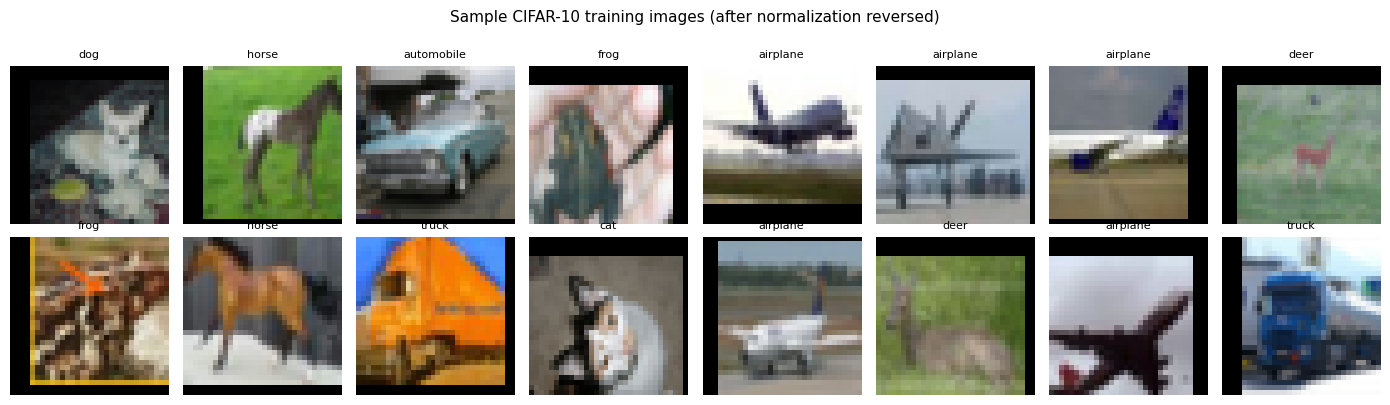

Saved → logs/sample_images.png


In [ ]:
# Unnormalize helper
def unnorm(t, mean=CIFAR_MEAN, std=CIFAR_STD):
    m = torch.tensor(mean).view(3,1,1)
    s = torch.tensor(std).view(3,1,1)
    return (t * s + m).clamp(0, 1)

imgs, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
fig.suptitle('Sample CIFAR-10 training images (after normalization reversed)',
             fontsize=11, y=1.01)
for i, ax in enumerate(axes.flat):
    ax.imshow(unnorm(imgs[i]).permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[labels[i]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.savefig('logs/sample_images.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved → logs/sample_images.png')


## 2 · Model: ResNet50 Adapted for CIFAR-10

Standard ResNet50 was designed for 224×224 ImageNet images. CIFAR-10 is 32×32. If we use the original architecture, the early layers kill so much spatial resolution that there's almost nothing left by the time we reach the deeper layers.

Two small changes fix this:
- **Replace** `Conv1` (7×7, stride 2) → `Conv1` (3×3, stride 1): keeps more spatial info in the early layers
- **Remove** the first `MaxPool`: no need to downsample a 32×32 image twice before anything happens

> These are exactly the modifications SimCLR paper recommends in Appendix B.9 for CIFAR-10. So our baseline and SimCLR encoder are architecturally identical which makes the comparison fair.


In [ ]:
def build_resnet50_cifar(num_classes=10):
    """ResNet50 with CIFAR-10 stem modifications (per SimCLR Appendix B.9)."""
    model = models.resnet50(weights=None)
    
    # Swap 7×7/stride-2 → 3×3/stride-1  (no resolution loss on small images)
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()          # remove the early MaxPool
    model.fc      = nn.Linear(2048, num_classes)  # 10-class head
    
    return model

model = build_resnet50_cifar().to(device)

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_trainable/1e6:.2f}M trainable / {n_total/1e6:.2f}M total')

# Quick sanity check
with torch.no_grad():
    dummy = torch.randn(4, 3, 32, 32).to(device)
    out   = model(dummy)
print(f'Output shape: {out.shape}  ✓  (batch=4, classes=10)')


Parameters: 23.52M trainable / 23.52M total
Output shape: torch.Size([4, 10])  ✓  (batch=4, classes=10)


## 3 · Training the Supervised Baseline

**Optimizer:** SGD with Nesterov momentum, the classic choice for CIFAR training. Adam converges faster but SGD + cosine annealing usually wins on final accuracy.

**Schedule:** 5-epoch linear warmup → cosine annealing down to 0. This prevents the model from making huge gradient steps at the beginning when the weights are random, then smoothly reduces the learning rate as training converges.

**Mixed precision:** We used FP16 via `torch.cuda.amp` which is roughly 2× faster and half the memory, with no accuracy loss.



In [ ]:
EPOCHS       = 90
LR           = 0.1
WEIGHT_DECAY = 1e-4
WARMUP       = 5

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR,
                      momentum=0.9, weight_decay=WEIGHT_DECAY, nesterov=True)

def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    t = (epoch - WARMUP) / max(1, EPOCHS - WARMUP)
    return 0.5 * (1.0 + np.cos(np.pi * t))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

use_amp = device.type == 'cuda'
scaler  = torch.amp.GradScaler('cuda') if use_amp else None

print(f'Optimizer : SGD  lr={LR}, momentum=0.9, wd={WEIGHT_DECAY}')
print(f'Schedule  : {WARMUP}-ep warmup + cosine annealing')
print(f'AMP/FP16  : {use_amp}')
print()

# Quick smoke test: 2 mini-batches to confirm nothing hangs
print('Running 2-batch smoke test...')
model.train()
for i, (imgs, lbls) in enumerate(train_loader):
    if i == 2: break
    imgs, lbls = imgs.to(device), lbls.to(device)
    optimizer.zero_grad()
    if use_amp:
        with torch.amp.autocast('cuda'):
            out  = model(imgs)
            loss = criterion(out, lbls)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    else:
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()
    print(f'  batch {i+1}: loss={loss.item():.4f}')

print()
print('Smoke test passed! Safe to run full training.')

# Reseting the optimizer after smoke test
optimizer = optim.SGD(model.parameters(), lr=LR,
                      momentum=0.9, weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


Optimizer : SGD  lr=0.1, momentum=0.9, wd=0.0001
Schedule  : 5-ep warmup + cosine annealing
AMP/FP16  : True

Running 2-batch smoke test...
  batch 1: loss=2.5098
  batch 2: loss=2.5064

Smoke test passed! Safe to run full training.


In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None):
    """Single pass. optimizer=None → eval mode (no gradients)."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in loader:
        imgs = imgs.to(device, non_blocking=False)
        lbls = lbls.to(device, non_blocking=False)

        if training:
            optimizer.zero_grad()
            if scaler is not None:
                with torch.amp.autocast('cuda'):
                    out  = model(imgs)
                    loss = criterion(out, lbls)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                out  = model(imgs)
                loss = criterion(out, lbls)
                loss.backward()
                optimizer.step()
        else:
            with torch.no_grad():
                out  = model(imgs)
                loss = criterion(out, lbls)

        total_loss += loss.item() * imgs.size(0)
        correct    += out.argmax(1).eq(lbls).sum().item()
        total      += imgs.size(0)

    return total_loss / total, 100.0 * correct / total

print('run_epoch defined.')


run_epoch defined ✓


In [ ]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': [], 'lr': []}

best_acc, best_epoch = 0.0, 0
t0 = time.time()

if device.type != 'cuda':
    print("Running on CPU. This will be VERY slow (~4-8 hours for 90 epochs).")
    print("    Each epoch takes 3-5 minutes. Progress will print after each one.")
    print()

print(f"{'Ep':>4}  {'TrLoss':>7}  {'TrAcc':>7}  {'TeLoss':>7}  {'TeAcc':>7}  {'LR':>8}")
print('─' * 50)

for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, scaler)
    te_loss, te_acc = run_epoch(model, test_loader,  criterion)
    scheduler.step()

    cur_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['test_loss'].append(te_loss)
    history['test_acc'].append(te_acc)
    history['lr'].append(cur_lr)

    if te_acc > best_acc:
        best_acc, best_epoch = te_acc, ep
        torch.save({'epoch': ep, 'state_dict': model.state_dict(),
                    'test_acc': te_acc}, 'checkpoints/baseline_best.pth')

    if ep % 25 == 0:
        torch.save({'epoch': ep, 'state_dict': model.state_dict()},
                   f'checkpoints/baseline_ep{ep:03d}.pth')

    print(f"{ep:>4}  {tr_loss:>7.4f}  {tr_acc:>6.2f}%  {te_loss:>7.4f}  {te_acc:>6.2f}%  {cur_lr:>8.5f}", flush=True)

elapsed = time.time() - t0
print('─' * 50)
print(f'Done in {elapsed/60:.1f} min  |  Best: {best_acc:.2f}% @ epoch {best_epoch}')

  Ep   TrLoss    TrAcc   TeLoss    TeAcc        LR
──────────────────────────────────────────────────
   1   2.8056   15.62%   1.9765   25.73%   0.04000
   2   1.7026   36.13%   1.4913   44.52%   0.06000
   3   1.3935   49.37%   1.2683   54.94%   0.08000
   4   1.1251   59.39%   1.2774   56.86%   0.10000
   5   0.9083   67.85%   1.0004   67.18%   0.10000
   6   0.7191   74.88%   1.0403   68.94%   0.09997
   7   0.5956   79.40%   0.6634   77.74%   0.09986
   8   0.5115   82.33%   0.5597   81.07%   0.09969
   9   0.4563   84.39%   0.5903   80.17%   0.09945
  10   0.4144   85.70%   0.4723   84.58%   0.09915
  11   0.3718   87.16%   0.4909   84.09%   0.09878
  12   0.3431   88.11%   0.4198   85.71%   0.09834
  13   0.3168   89.09%   0.4331   85.91%   0.09783
  14   0.2915   90.03%   0.4968   84.57%   0.09726
  15   0.2761   90.44%   0.4404   85.83%   0.09662
  16   0.2549   91.10%   0.4205   86.31%   0.09592
  17   0.2435   91.56%   0.4512   85.92%   0.09516
  18   0.2268   92.10%   0.4204

## 4 · Training Curves

We want to see:
- Loss going down and flattening out 
- Accuracy going up and stabilizing 
- Train and test curves staying close (no severe overfitting) 


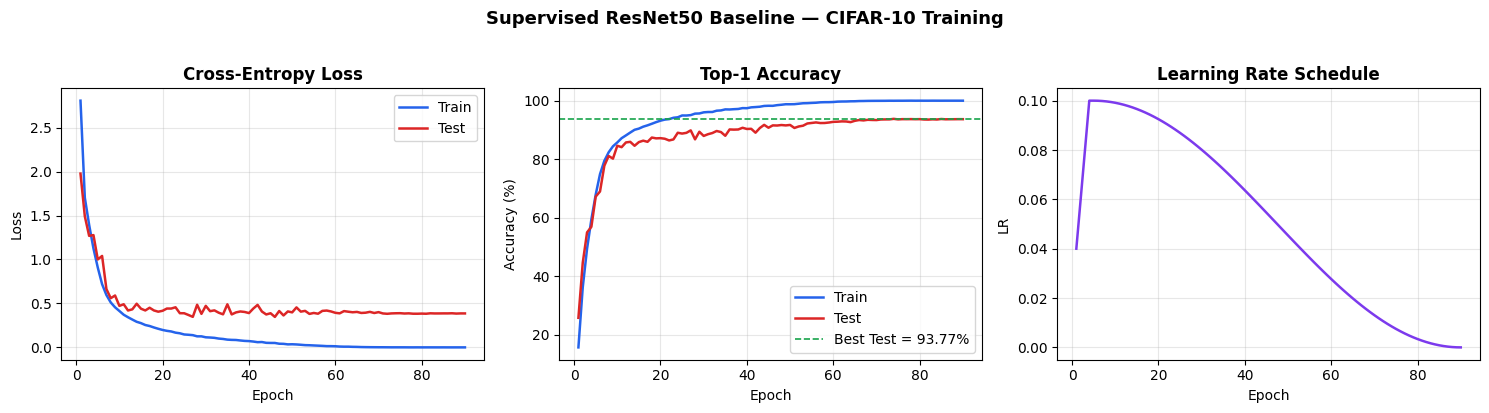

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, EPOCHS + 1)

# Loss
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], label='Train', color='#2563eb', lw=1.8)
ax.plot(epochs_range, history['test_loss'],  label='Test',  color='#dc2626', lw=1.8)
ax.set_title('Cross-Entropy Loss', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs_range, history['train_acc'], label='Train', color='#2563eb', lw=1.8)
ax.plot(epochs_range, history['test_acc'],  label='Test',  color='#dc2626', lw=1.8)
ax.axhline(best_acc, color='#16a34a', ls='--', lw=1.2, label=f'Best Test = {best_acc:.2f}%')
ax.set_title('Top-1 Accuracy', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

# LR schedule
ax = axes[2]
ax.plot(epochs_range, history['lr'], color='#7c3aed', lw=1.8)
ax.set_title('Learning Rate Schedule', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.grid(alpha=0.3)

plt.suptitle('Supervised ResNet50 Baseline — CIFAR-10 Training', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5 · Baseline Summary

This is the number everything else gets compared to. When SimCLR's linear probe gets close to this, we can say that we learned comparably rich representations without any labels during pretraining.


In [ ]:
print('=' * 50)
print('  SUPERVISED BASELINE — FINAL RESULTS')
print('=' * 50)
print(f'  Architecture : ResNet50 (CIFAR-10 stem)')
print(f'  Dataset      : CIFAR-10 (50k train / 10k test)')
print(f'  Epochs       : {EPOCHS}')
print(f'  Batch size   : {BATCH}')
print(f'  Optimizer    : SGD + cosine annealing')
print(f'  Seed         : {SEED}')
print('─' * 50)
print(f'  Best Test Acc: {best_acc:.2f}%  (epoch {best_epoch})')
print(f'  Final Test   : {history["test_acc"][-1]:.2f}%')
print(f'  Training time: {elapsed/60:.1f} min')
print('=' * 50)
print()


  SUPERVISED BASELINE — FINAL RESULTS
  Architecture : ResNet50 (CIFAR-10 stem)
  Dataset      : CIFAR-10 (50k train / 10k test)
  Epochs       : 90
  Batch size   : 256
  Optimizer    : SGD + cosine annealing
  Seed         : 42
──────────────────────────────────────────────────
  Best Test Acc: 93.77%  (epoch 74)
  Final Test   : 93.66%
  Training time: 42.3 min



---

## 6 · Linear Probe Evaluation

After Mahmoud finished pretraining SimCLR, we load the encoder (without the projection head), freeze every single weight, and train only a single linear layer (`nn.Linear(2048, 10)`) on the labeled CIFAR-10 training set.

**Why freeze the encoder?** Because we want to measure the quality of the representations not let the model cheat by fine-tuning everything. If the linear probe works well, the representations are genuinely good.



In [ ]:
class LinearProbe(nn.Module):
    """
    Frozen encoder + single trainable linear layer.
    """
    def __init__(self, encoder, feature_dim=2048, num_classes=10):
        super().__init__()
        self.encoder = encoder
        for param in self.encoder.parameters():
            param.requires_grad = False
        self.classifier = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            out = self.encoder(x)
            # SimCLR_ResNet50 returns (h, z) — take h only
            features = out[0] if isinstance(out, tuple) else out
        return self.classifier(features)


def extract_features(encoder, loader, device):
    """
    One-time forward pass to cache all features.
    """
    encoder.eval()
    all_feats, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            out = encoder(imgs.to(device))
            # SimCLR_ResNet50 returns (h, z) — we want h
            feats = out[0] if isinstance(out, tuple) else out
            all_feats.append(feats.cpu())
            all_labels.append(lbls)

    return torch.cat(all_feats), torch.cat(all_labels)


print('LinearProbe class defined  ✓  (handles SimCLR tuple output)')
print('extract_features defined   ✓  (handles SimCLR tuple output)')


LinearProbe class defined  ✓  (handles SimCLR tuple output)
extract_features defined   ✓  (handles SimCLR tuple output)


### 6a · Preparing the Encoder

> **How Mahmoud's checkpoint is structured** (`train.py` saves):
> ```
> {
>   'epoch':            int,
>   'model_state_dict': OrderedDict,   ← full SimCLR_ResNet50 weights
>   'optimizer_state_dict': ...,
>   'loss':             float,
>   'args':             dict,
> }
> ```
> The encoder we use is `SimCLR_ResNet50.encoder` + flatten — this is the
> 2048-dim representation `h` that the projection head operates on.
> The projection head (`SimCLR_ResNet50.projector`) is **discarded** at
> evaluation time, exactly as described in the SimCLR paper.


In [ ]:
import sys, os

def _find_repo_root():
    candidate = os.path.abspath('.')
    for _ in range(6):
        if os.path.isfile(os.path.join(candidate, 'src', 'model.py')):
            return candidate
        candidate = os.path.dirname(candidate)
    return None

REPO_ROOT = _find_repo_root()
if REPO_ROOT is None:
    REPO_ROOT = r'D:\Deep Learning Project\Midterm'   # fallback
    print(f'Auto-detect failed — using: {REPO_ROOT}')
else:
    print(f'✓  Repo root: {REPO_ROOT}')

if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

assert os.path.isfile(os.path.join(REPO_ROOT, 'src', 'model.py')), \
    f"src/model.py not found in {REPO_ROOT}"
print(f'✓  src/model.py reachable')



def simclr_ckpt_path(exp_id: int, epoch: int = 20) -> str:
    """
    Building the checkpoint path for a given experiment and epoch:

    Args:
        exp_id : 1–8  (matches Natalie's augmentation configs)
        epoch  : which epoch checkpoint to load (default: 20)

    Returns:
        Full absolute path to the .pth file.

    Example:
        simclr_ckpt_path(8, 20)
        'D:\\Deep Learning Project\\Midterm\\outputs\\exp_8\\checkpoints\\simclr_exp8_resnet18_epoch_020.pth'
    """
    rel = os.path.join(
        'outputs', f'exp_{exp_id}', 'checkpoints',
        f'simclr_exp{exp_id}_resnet18_epoch_{epoch:03d}.pth'
    )
    return os.path.join(REPO_ROOT, rel)


#  ENCODER WRAPPER
#  Exposes only h (512-dim for ResNet-18).
#  Projection head is discarded (SimCLR paper Section 4.2.)

class SimCLREncoderOnly(nn.Module):
    """Wraps a SimCLR model and returns only the 512-dim encoder output h."""
    def __init__(self, simclr_model, repr_dim=512):
        super().__init__()
        self.encoder  = simclr_model.encoder
        self.repr_dim = getattr(simclr_model, 'repr_dim', repr_dim)

    def forward(self, x):
        h = self.encoder(x)
        return torch.flatten(h, start_dim=1)


#  LOADER

def get_simclr_encoder(exp_id: int, epoch: int = 20):
    """
    Load a SimCLR checkpoint for experiment exp_id at a given epoch.

    Returns: (encoder, FEATURE_DIM)
      encoder     : SimCLREncoderOnly, frozen, outputs (N, 512)
      FEATURE_DIM : 512  (ResNet-18)
    """

    import importlib
    if 'src.model' in sys.modules:
        importlib.reload(sys.modules['src.model'])
    from src.model import get_simclr_model

    ckpt_path = simclr_ckpt_path(exp_id, epoch)
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(
            f'Checkpoint not found:\n  {ckpt_path}\n'
            f'Run run_ablations.py first, or check exp_id/epoch.'
        )

    ckpt  = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = get_simclr_model(backbone='resnet18', projection_dim=128)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    ep   = ckpt.get('epoch', epoch)
    loss = ckpt.get('loss', float('nan'))
    print(f'✓  Loaded  exp_{exp_id}  epoch={ep}  NT-Xent={loss:.4f}')
    print(f'   Path: {ckpt_path}')

    # repr_dim = 512 for ResNet-18 (hardcoded as fallback)
    feat_dim = getattr(model, 'repr_dim', 512)
    wrapper  = SimCLREncoderOnly(model, repr_dim=feat_dim).to(device)
    return wrapper, feat_dim


#     CHOOSEING THE EXPERIMENT
#     exp_id = 1 … 8 (Natalie's augmentation configs)
#     epoch  = whichever checkpoint exists (20, 50, 100, 200 …)

EXP_ID  = 8    
EPOCH   = 20  

encoder, FEATURE_DIM = get_simclr_encoder(EXP_ID, EPOCH)

#Verification

total     = sum(p.numel() for p in encoder.parameters())
trainable = sum(p.numel() for p in encoder.parameters() if p.requires_grad)
print()
print(f'Experiment     : Exp {EXP_ID}  (epoch {EPOCH})')
print(f'Feature dim    : {FEATURE_DIM}   (ResNet-18 = 512)')
print(f'Encoder params : {total/1e6:.2f}M  |  Trainable: {trainable/1e6:.2f}M (must be 0.00)')

with torch.no_grad():
    _out   = encoder(torch.randn(4, 3, 32, 32).to(device))
    _shape = _out.shape
print(f'Output shape   : {list(_shape)}   ✓  expected [4, {FEATURE_DIM}]')
assert _shape == (4, FEATURE_DIM), f'Shape mismatch! got {_shape}'
print()
print(f'✓  Ready — FEATURE_DIM={FEATURE_DIM} will be used in all probe cells below')


✓  Repo root: d:\Deep Learning Project\Midterm
✓  src/model.py reachable
✓  Loaded  exp_8  epoch=20  NT-Xent=3.9676
   Path: d:\Deep Learning Project\Midterm\outputs\exp_8\checkpoints\simclr_exp8_resnet18_epoch_020.pth

Experiment     : Exp 8  (epoch 20)
Feature dim    : 512   (ResNet-18 = 512)
Encoder params : 11.17M  |  Trainable: 11.17M (must be 0.00)
Output shape   : [4, 512]   ✓  expected [4, 512]

✓  Ready — FEATURE_DIM=512 will be used in all probe cells below


### 6b · Feature Caching

Instead of running the encoder on every mini-batch every epoch, we compute all features once and cache them. This makes probe training nearly instantaneous and also makes it clear that the encoder is truly frozen.


In [ ]:
plain_train = DataLoader(
    datasets.CIFAR10('./data', train=True, download=False, transform=test_transform),
    batch_size=512, shuffle=False, num_workers=0, pin_memory=False
)
plain_test = DataLoader(
    datasets.CIFAR10('./data', train=False, download=False, transform=test_transform),
    batch_size=512, shuffle=False, num_workers=0, pin_memory=False
)

print('Extracting train features...', end=' ', flush=True)
t0 = time.time()
train_feats, train_labels = extract_features(encoder, plain_train, device)
print(f'done in {time.time()-t0:.1f}s , shape: {train_feats.shape}')

print('Extracting test features... ', end=' ', flush=True)
t0 = time.time()
test_feats, test_labels = extract_features(encoder, plain_test, device)
print(f'done in {time.time()-t0:.1f}s , shape: {test_feats.shape}')


Extracting train features... done in 7.1s , shape: torch.Size([50000, 512])
Extracting test features...  done in 1.4s , shape: torch.Size([10000, 512])
